# 📊 Flagging Vendor Invoices for Manual Review

**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

- Manual invoice review is time-consuming and does not scale well with transaction volume.
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect(r"C:\Users\Ratna\OneDrive\Desktop\webdev\Ai learning stuff\Invoice-Intelligence-System\inventory.db")


In [3]:

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
for tables in tables['name']:
    print( f'Table name: {tables}')
    display(pd.read_sql(f"select * from {tables} limit 5", conn) )
            
print(tables)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


end_inventory


In [4]:
purchase_agg_df = pd.read_sql_query("""
SELECT 
    p.PONumber,
    COUNT(distinct p.Brand) as total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
""", conn)

In [5]:
purchase_agg_df = pd.read_sql_query("""
SELECT 
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
""", conn)

In [6]:
query = """
SELECT 
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
"""
print(query)
pd.read_sql_query(query, conn)


SELECT 
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber



,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [7]:
pd.read_sql_query("""
SELECT 
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(p.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
FROM vendor_invoice vi
JOIN purchases p 
    ON vi.PONumber = p.PONumber
""", conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,15,140.55,8.57,16.0,45.0
3,15,140.55,8.57,16.0,45.0
4,5,106.60,4.61,16.0,38.0
...,...,...,...,...,...
2372469,437,3608.11,16.60,17.0,38.0
2372470,437,3608.11,16.60,17.0,38.0
2372471,437,3608.11,16.60,17.0,38.0
2372472,437,3608.11,16.60,17.0,38.0


In [8]:
purchase_agg_df.shape

(5543, 5)

In [9]:
purchase_invoice_df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT 
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT 
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

In [10]:
purchase_invoice_df.describe()
purchase_invoice_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   invoice_quantity     5543 non-null   int64  
 2   invoice_dollars      5543 non-null   float64
 3   Freight              5543 non-null   float64
 4   days_po_to_invoice   5543 non-null   float64
 5   days_to_pay          5543 non-null   float64
 6   total_brands         5543 non-null   int64  
 7   total_item_quantity  5543 non-null   int64  
 8   total_item_dollars   5543 non-null   float64
 9   avg_receiving_delay  5543 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 433.2 KB


In [11]:
purchase_invoice_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [12]:
def create_invoice_risk_label(row):
    
    if pd.notnull(row["invoice_dollars"]) and pd.notnull(row["total_item_dollars"]):
        if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
            return 1
    
    if pd.notnull(row["avg_receiving_delay"]):
        if row["avg_receiving_delay"] > 10:
            return 1
    
    return 0

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [14]:
def create_invoice_risk_label(row):
    
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1
    
    if row["avg_receiving_delay"] > 10:
        return 1
    
    return 0

In [15]:
purchase_invoice_df["flag_invoice"] = purchase_invoice_df.apply(create_invoice_risk_label, axis=1)

In [16]:
purchase_invoice_df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

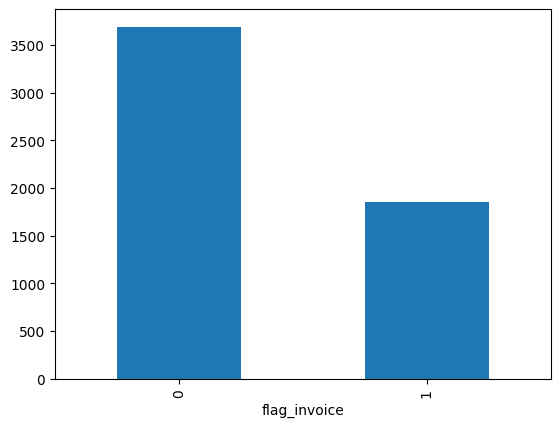

In [17]:
purchase_invoice_df['flag_invoice'].value_counts().plot(kind='bar')

In [18]:
purchase_invoice_df.columns

Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay',
       'flag_invoice'],
      dtype='str')

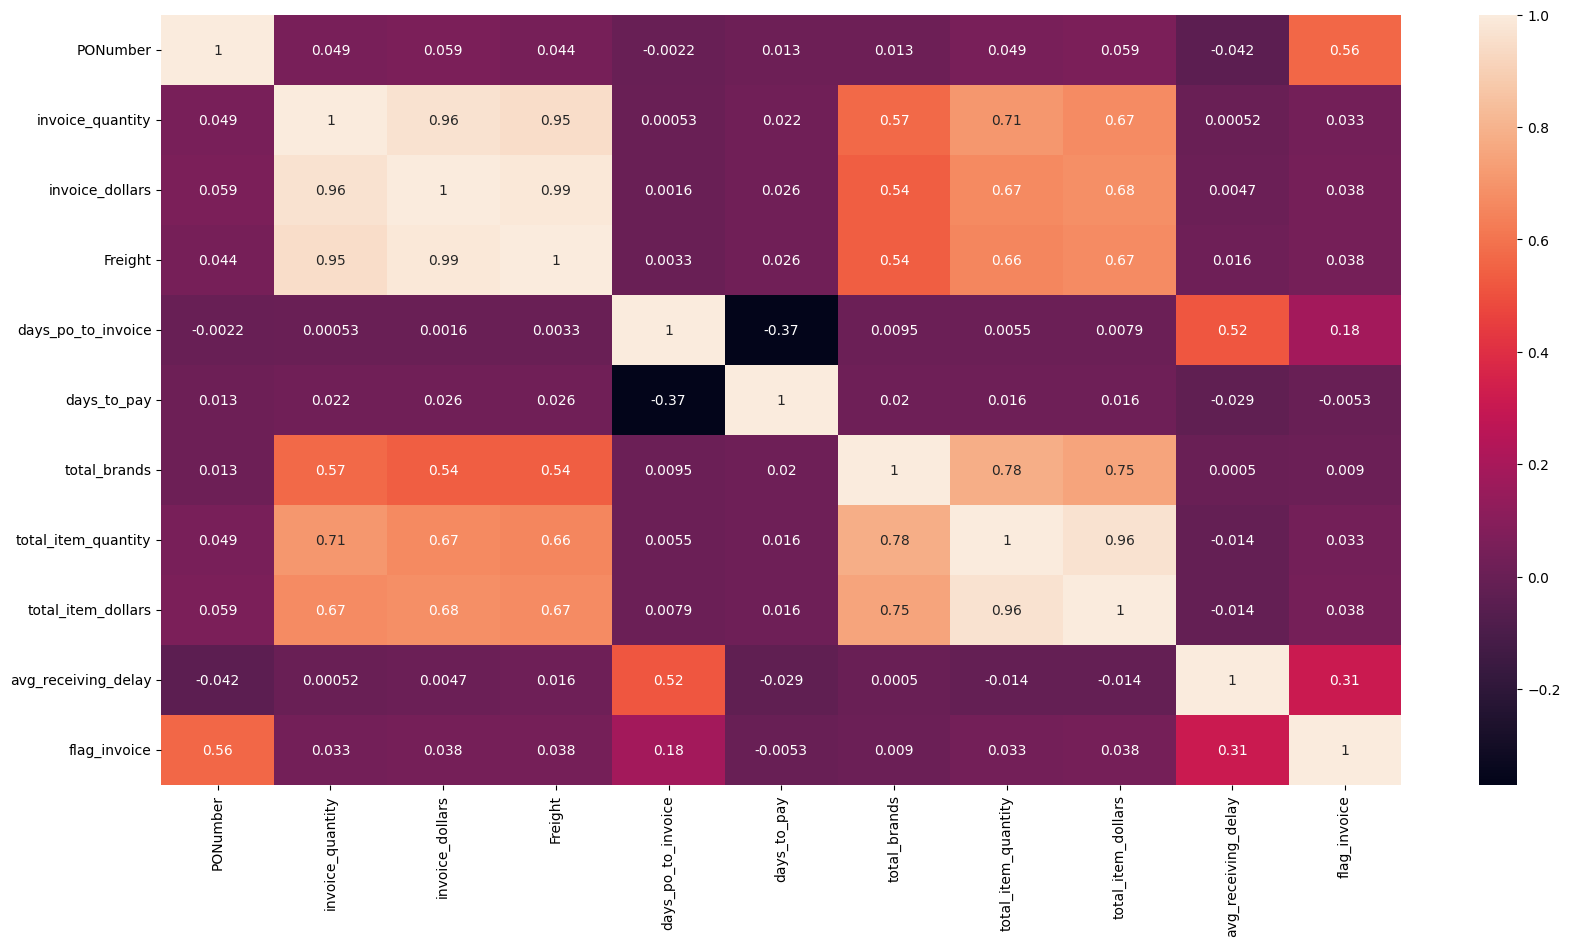

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,10))
sns.heatmap(purchase_invoice_df.corr(), annot=True)
plt.show()

In [20]:
from scipy.stats import ttest_ind

# Initialize lists
results = []
significant_features = []
non_significant_features = []

# Split dataset
flagged = purchase_invoice_df[purchase_invoice_df['flag_invoice'] == 1]
normal = purchase_invoice_df[purchase_invoice_df['flag_invoice'] == 0]

# Only numeric columns
numeric_cols = purchase_invoice_df.select_dtypes(include='number').columns

# Loop
for col in numeric_cols:
    if col != 'flag_invoice':
        
        flagged_vals = flagged[col].dropna()
        normal_vals = normal[col].dropna()
        
        if len(flagged_vals) > 0 and len(normal_vals) > 0:
            stat, p_value = ttest_ind(flagged_vals, normal_vals)
            
            results.append((col, p_value))
            
            if p_value < 0.05:
                significant_features.append(col)
            else:
                non_significant_features.append(col)


In [21]:
pd.read_sql_query("""
SELECT 
    vi.PONumber,
    vi.Quantity,
    vi.Dollars,
    vi.Freight,

    -- Time Features
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,

    -- Derived Features
    (vi.Dollars / NULLIF(vi.Quantity, 0)) AS price_per_unit,
    (vi.Freight / NULLIF(vi.Quantity, 0)) AS freight_per_unit

FROM vendor_invoice vi
""", conn)

,PONumber,Quantity,Dollars,Freight,days_po_to_invoice,days_to_pay,price_per_unit,freight_per_unit
0,8124,6,214.26,3.47,14.0,43.0,35.710000,0.578333
1,8137,15,140.55,8.57,16.0,45.0,9.370000,0.571333
2,8169,5,106.60,4.61,16.0,38.0,21.320000,0.922000
3,8106,10100,137483.78,2935.20,23.0,24.0,13.612255,0.290614
4,8170,1935,15527.25,429.20,14.0,36.0,8.024419,0.221809
...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,17.366667,0.095556
5539,13661,4617,37300.48,186.50,18.0,39.0,8.078943,0.040394
5540,13643,9848,202815.78,932.95,11.0,33.0,20.594616,0.094735
5541,13602,24747,149007.56,819.54,14.0,36.0,6.021237,0.033117


In [22]:
print("Significant Features:")
print(significant_features)

Significant Features:
['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']


In [23]:
print("\nNon-Significant Features:")
print(non_significant_features)


Non-Significant Features:
['days_to_pay', 'total_brands']


In [24]:
import pandas as pd

results_df = pd.DataFrame(results, columns=['Feature', 'P-Value'])
results_df.sort_values(by='P-Value')

,Feature,P-Value
0,PONumber,0.000000e+00
9,avg_receiving_delay,3.862719e-125
4,days_po_to_invoice,5.346707e-43
2,invoice_dollars,4.667937e-03
8,total_item_dollars,4.667942e-03
3,Freight,4.930377e-03
1,invoice_quantity,1.465210e-02
7,total_item_quantity,1.465258e-02
6,total_brands,5.047674e-01
5,days_to_pay,6.938048e-01


In [25]:
from scipy.stats import ttest_ind

metrics = [
    'invoice_quantity', 'invoice_dollars', 'Freight',
    'days_po_to_invoice', 'days_to_pay', 'total_brands',
    'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay'
]

significant_features = []
non_significant_features = []
results = []

for metric in metrics:
    
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    
    if p_value < 0.05:
        significant_features.append(metric)
    else:
        non_significant_features.append(metric)
    
    results.append({
        "metric": metric,
        "flagged_mean": round(flagged_mean, 2),
        "normal_mean": round(normal_mean, 2),
        "p_value": round(p_value, 4)
    })

In [26]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df.sort_values(by="p_value")

,metric,flagged_mean,normal_mean,p_value
3,days_po_to_invoice,17.23,16.02,0.0000
8,avg_receiving_delay,8.47,7.27,0.0000
1,invoice_dollars,65600.61,54302.64,0.0080
7,total_item_dollars,65600.61,54302.64,0.0080
2,Freight,334.02,276.89,0.0082
0,invoice_quantity,6728.28,5723.55,0.0213
6,total_item_quantity,6728.28,5723.55,0.0213
5,total_brands,42.29,40.82,0.5077
4,days_to_pay,35.42,35.49,0.6924


In [27]:
X = purchase_invoice_df[significant_features]
y = purchase_invoice_df['flag_invoice']

In [28]:
X.describe().round()


,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
X = purchase_invoice_df[significant_features]
y = purchase_invoice_df['flag_invoice']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": model1,
    "Decision Tree": model2,
    "Random Forest": model3
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.739404869251578
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.38      0.50       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.66      1109
weighted avg       0.74      0.74      0.71      1109


Decision Tree
Accuracy: 0.9486023444544635
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       725
           1       0.95      0.90      0.92       384

    accuracy                           0.95      1109
   macro avg       0.95      0.94      0.94      1109
weighted avg       0.95      0.95      0.95      1109


Random Forest
Accuracy: 0.9558160504959423
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
           1       1.00      0.87      0.93       384

    accuracy                           0.96  

In [35]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

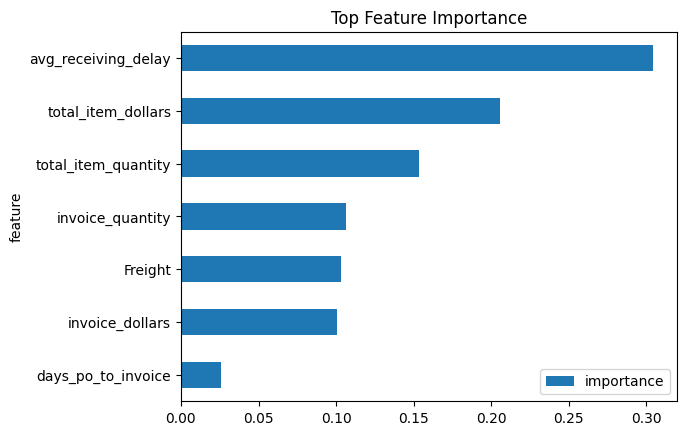

In [36]:
import matplotlib.pyplot as plt

feature_importance.head(10).sort_values(by="importance").plot(
    kind='barh', x='feature', y='importance'
)

plt.title("Top Feature Importance")
plt.show()

In [37]:
X = purchase_invoice_df[['invoice_quantity', 'invoice_dollars', 'Freight', 
                         'total_item_quantity', 'total_item_dollars']]

y = purchase_invoice_df['flag_invoice']

In [38]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [39]:
# Train
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

# Evaluate
evaluate_model(model3, X_test_scaled, y_test, "Random Forest")


Random Forest
Accuracy: 0.9558160504959423
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
           1       1.00      0.87      0.93       384

    accuracy                           0.96      1109
   macro avg       0.97      0.94      0.95      1109
weighted avg       0.96      0.96      0.96      1109



In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Features & Target
X = purchase_invoice_df[['invoice_quantity', 'invoice_dollars', 'Freight', 
                         'total_item_quantity', 'total_item_dollars']]
y = purchase_invoice_df['flag_invoice']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

# Evaluate
evaluate_model(model3, X_test_scaled, y_test, "Random Forest")


Random Forest
Accuracy: 0.8845807033363391
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

# Model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter Grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

# Scoring (important for imbalance)
scorer = make_scorer(f1_score)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Train
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [42]:
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [43]:
evaluate_model(best_model, X_test_scaled, y_test, "Tuned Random Forest")


Tuned Random Forest
Accuracy: 0.8899909828674482
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



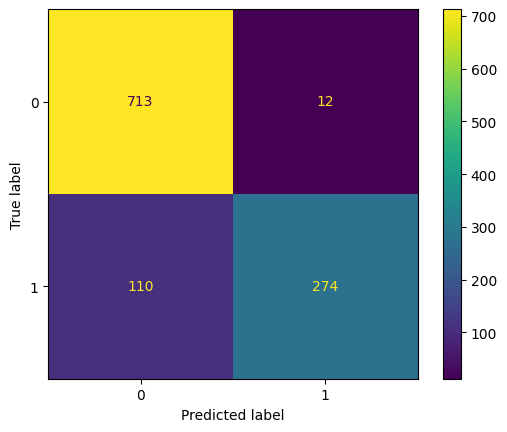

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test_scaled,
    y_test
)

In [45]:
from sklearn.metrics import recall_score

y_pred = grid_search.predict(X_test_scaled)
recall_score(y_test, y_pred)

0.7135416666666666